In [5]:
import pandas as pd

file_path = r
df = pd.read_csv(file_path)

def basic_eda(dataframe):#欠損値の割合知りたいのと追加でカテゴリ列の確認全部出力するから多いと見にくくなる
    print('========== dataframe.info =============================')
    dataframe.info()

    print('\n========== 行数・列数 =============================')
    print(dataframe.shape)

    col_count = dataframe.shape[1]

    if col_count >= 20:
        print(f"警告: 列数が{col_count}列あります。列が多い")#目視で確認がだるいからね
    
    print('\n========== 欠損値の割合 10%以上 ======================')#10%は品質の確認必要な値として
    missing_rate = dataframe.isna().mean() * 100
    high_missing_rate = missing_rate[missing_rate >= 10].sort_values(ascending=False)

    print(high_missing_rate)
    
    print('\n========== カテゴリ列の確認 ======================')
    cat_cols = dataframe.select_dtypes(include=["object", "category", "string"]).columns
    
    for col in cat_cols:
        unique_count = dataframe[col].nunique(dropna=False)

        print(f'\n============== {col} の確認 =================')
        print(f'種類数: {unique_count}')
    
        if unique_count <= 20:
            print(f'=========== {col} の中身 ===========')
            print(dataframe[col].value_counts(dropna=False))

    return high_missing_rate

low_quality_col = basic_eda(df)

========== dataframe.info =============================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 

In [7]:
new_df = df.copy().drop(columns=low_quality_col.index.tolist()).drop("Id", axis=1)#欠損値10%以上はとりあえず除去#IDも除去#新しいdfを組む
new_df.info()
col_count = new_df.shape[1]
print(col_count)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 73 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotArea        1460 non-null   int64  
 3   Street         1460 non-null   object 
 4   LotShape       1460 non-null   object 
 5   LandContour    1460 non-null   object 
 6   Utilities      1460 non-null   object 
 7   LotConfig      1460 non-null   object 
 8   LandSlope      1460 non-null   object 
 9   Neighborhood   1460 non-null   object 
 10  Condition1     1460 non-null   object 
 11  Condition2     1460 non-null   object 
 12  BldgType       1460 non-null   object 
 13  HouseStyle     1460 non-null   object 
 14  OverallQual    1460 non-null   int64  
 15  OverallCond    1460 non-null   int64  
 16  YearBuilt      1460 non-null   int64  
 17  YearRemodAdd   1460 non-null   int64  
 18  RoofStyl

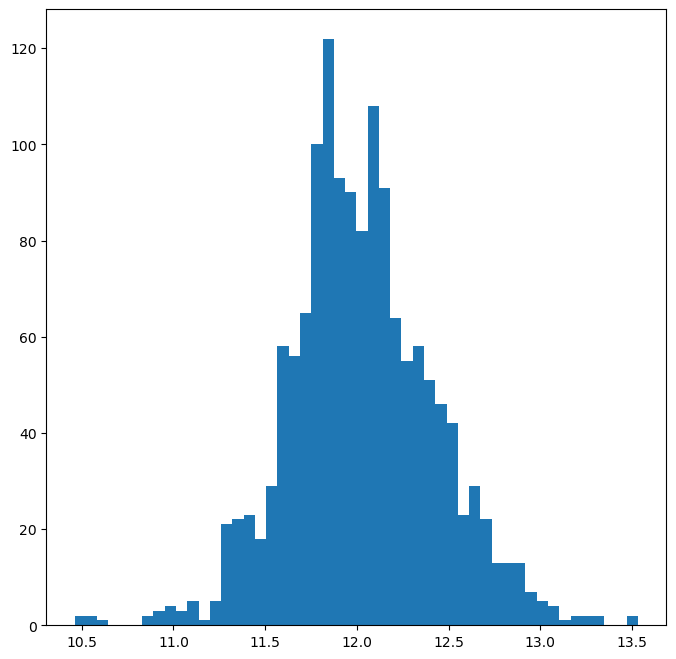

In [9]:
import matplotlib.pyplot as plt
import numpy as np

target=new_df["SalePrice"]
train=new_df

y=np.log1p(target)

plt.figure(figsize=(8,8))
plt.hist(y,bins=50)
plt.show()

In [11]:
import pandas as pd
#新しい特徴量を作成
new_df["TotalSF"] = (
    new_df["TotalBsmtSF"]
    + new_df["1stFlrSF"]
    + new_df["2ndFlrSF"]
)
new_df["HasPool"] = (new_df["PoolArea"] > 0).astype(int)
new_df["HasGarage"] = (new_df["GarageArea"] > 0).astype(int)
new_df["HasFireplace"] = (new_df["Fireplaces"] > 0).astype(int)
new_df["HouseAge"] = new_df["YrSold"] - new_df["YearBuilt"]
new_df["RemodAge"] = new_df["YrSold"] - new_df["YearRemodAdd"]
new_df["TotalBathrooms"] = (
    new_df["FullBath"]
    + 0.5 * new_df["HalfBath"]
    + new_df["BsmtFullBath"]
    + 0.5 * new_df["BsmtHalfBath"]
)
print("完了")

完了


In [13]:
import pandas as pd

def judge(dataframe):#カテゴリ列と数値列を分けたい
    categorical_features = dataframe.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    numerical_features = dataframe.select_dtypes(
        include=["number"]
    ).columns.tolist()

    return categorical_features, numerical_features

cat_features,num_features=judge(new_df)

cat_features.append("MSSubClass")
num_features.remove("MSSubClass")#目視で除去した
num_features.remove('SalePrice')

print("カテゴリ変数:",cat_features)
print("数値:",num_features)

カテゴリ変数: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition', 'MSSubClass']
数値: ['LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrS

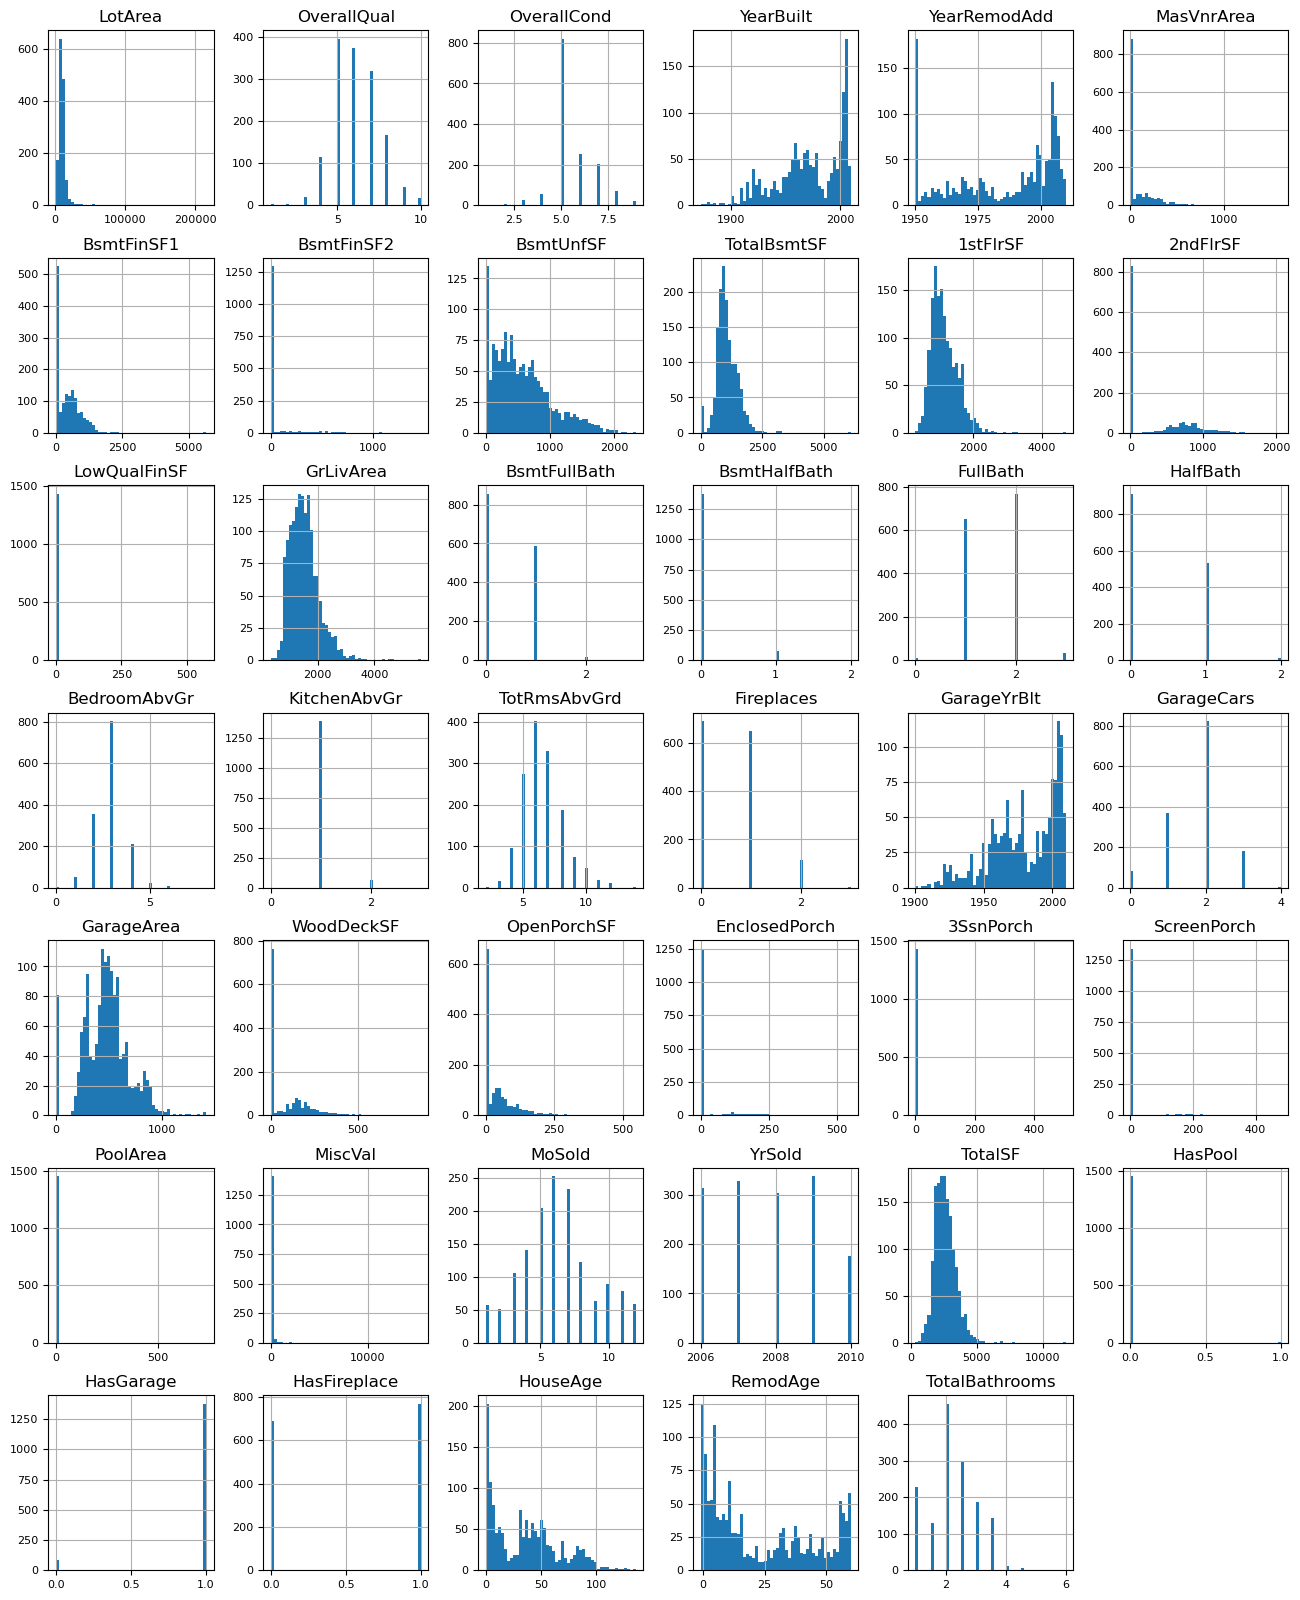

In [15]:
new_df[num_features].hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

In [16]:
import pandas as pd 
import numpy as np


from sklearn.model_selection import train_test_split, KFold, cross_val_score#CV用ライブラリ

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer#前処理用ライブラリ

from sklearn.ensemble import RandomForestRegressor#モデル
from xgboost import XGBRegressor
import lightgbm as lgb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


transformer1 = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("to_str", FunctionTransformer(
        lambda x: x.astype(str),
        feature_names_out="one-to-one"
    )),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Transformer2（数値）
transformer2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))           # 中央値補完
])

# ColumnTransformerカテゴリと数値を分けて処理
preprocessor = ColumnTransformer([
    ("cat", transformer1, cat_features),
    ("num", transformer2, num_features)
])

#パイプライン作成ハイパーパラメータは適当にいれた探索してない
rf_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=250,
        min_samples_leaf=5,
        random_state=43,
        n_jobs=-1
    ))
])

xgb_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", XGBRegressor(
        n_estimators=250,
        min_child_weight=5,
        random_state=43,
        n_jobs=-1
    ))
])

lgb_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", lgb.LGBMRegressor(
        n_estimators=250,
        min_child_samples=5,
        random_state=43,
        verbose=-1,
        n_jobs=-1
    ))
])

#交差検証準備
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#パイプ通したモデルリスト
pipelines = {
    "RandomForest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "lightGBM":lgb_pipeline
}
print("完了")

完了


In [17]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.base import clone


x = train.drop("SalePrice", axis=1)
y = np.log1p(target)

scores = np.zeros(5)
oof_pred = np.zeros(len(x))

pipelines = {
    "RandomForest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "lightGBM":lgb_pipeline
}
for i, (train_idx, valid_idx) in enumerate(kf.split(x)):
    x_train = x.iloc[train_idx]
    x_valid = x.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    # foldごとに未学習のPipelineを複製
    for name,pipeline in pipelines.items():
        fold_pipeline = clone(pipeline)
        
        # 前処理もモデルも、X_trainだけでfitされる
        fold_pipeline.fit(x_train, y_train)
    
        pred = fold_pipeline.predict(x_valid)
    
        rmse = root_mean_squared_error(y_valid, pred)
        scores[i - 1] = rmse
        oof_pred[valid_idx] = pred
        
        print(name)
        print(f"Fold {i}: RMSE = {rmse:.4f}")


RandomForest
Fold 0: RMSE = 0.1503
XGBoost
Fold 0: RMSE = 0.1468
lightGBM
Fold 0: RMSE = 0.1428
RandomForest
Fold 1: RMSE = 0.1264
XGBoost
Fold 1: RMSE = 0.1276
lightGBM
Fold 1: RMSE = 0.1188
RandomForest
Fold 2: RMSE = 0.1723
XGBoost
Fold 2: RMSE = 0.1743
lightGBM
Fold 2: RMSE = 0.1724
RandomForest
Fold 3: RMSE = 0.1465
XGBoost
Fold 3: RMSE = 0.1406
lightGBM
Fold 3: RMSE = 0.1349
RandomForest
Fold 4: RMSE = 0.1252
XGBoost
Fold 4: RMSE = 0.1245
lightGBM
Fold 4: RMSE = 0.1096


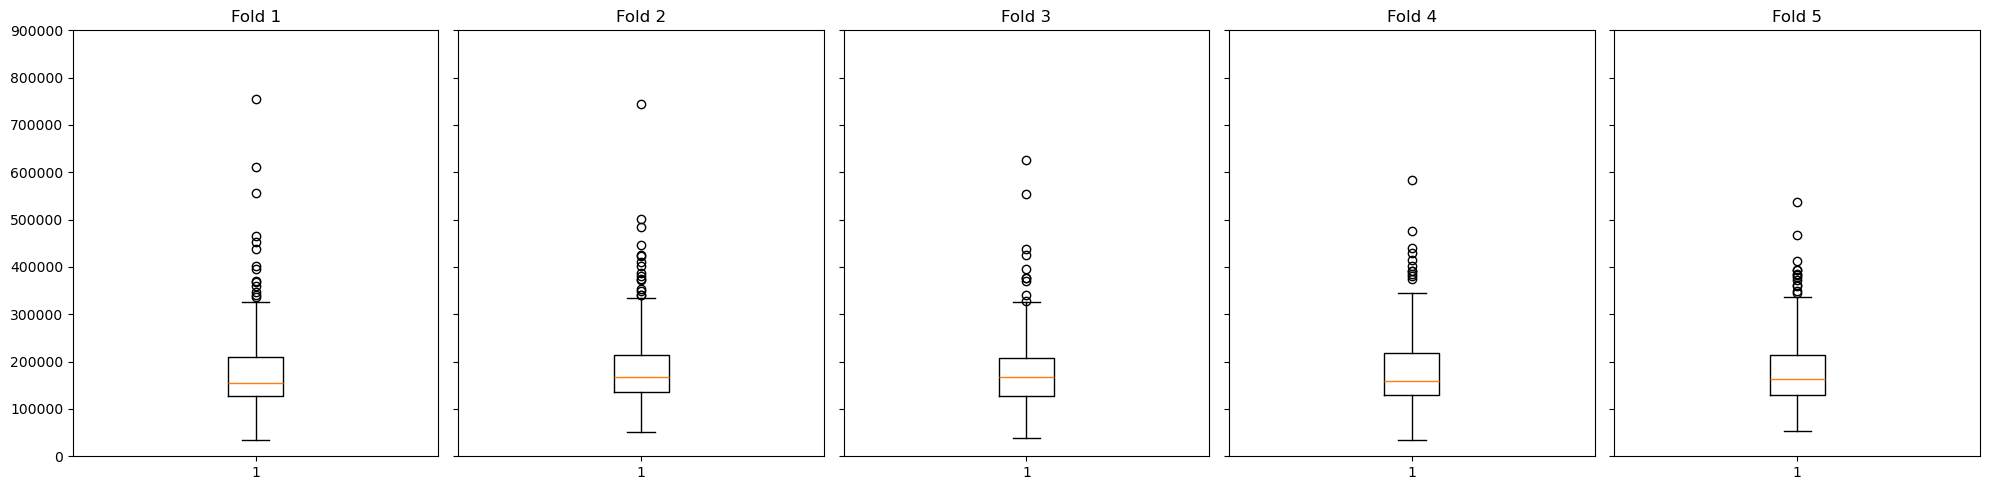

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for i, (train_idx, valid_idx) in enumerate(kf.split(x)):
    x_train = x.iloc[train_idx]
    x_valid = x.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    axes[i].boxplot(np.exp(y_valid))
    axes[i].set_title(f"Fold {i+1}")
    axes[i].set_ylim(0, 900000)

plt.tight_layout()
plt.savefig(r"C:\Users\81805\python_practice\2026_8_6Y_valid_box.png", dpi=300, bbox_inches="tight")
plt.show()

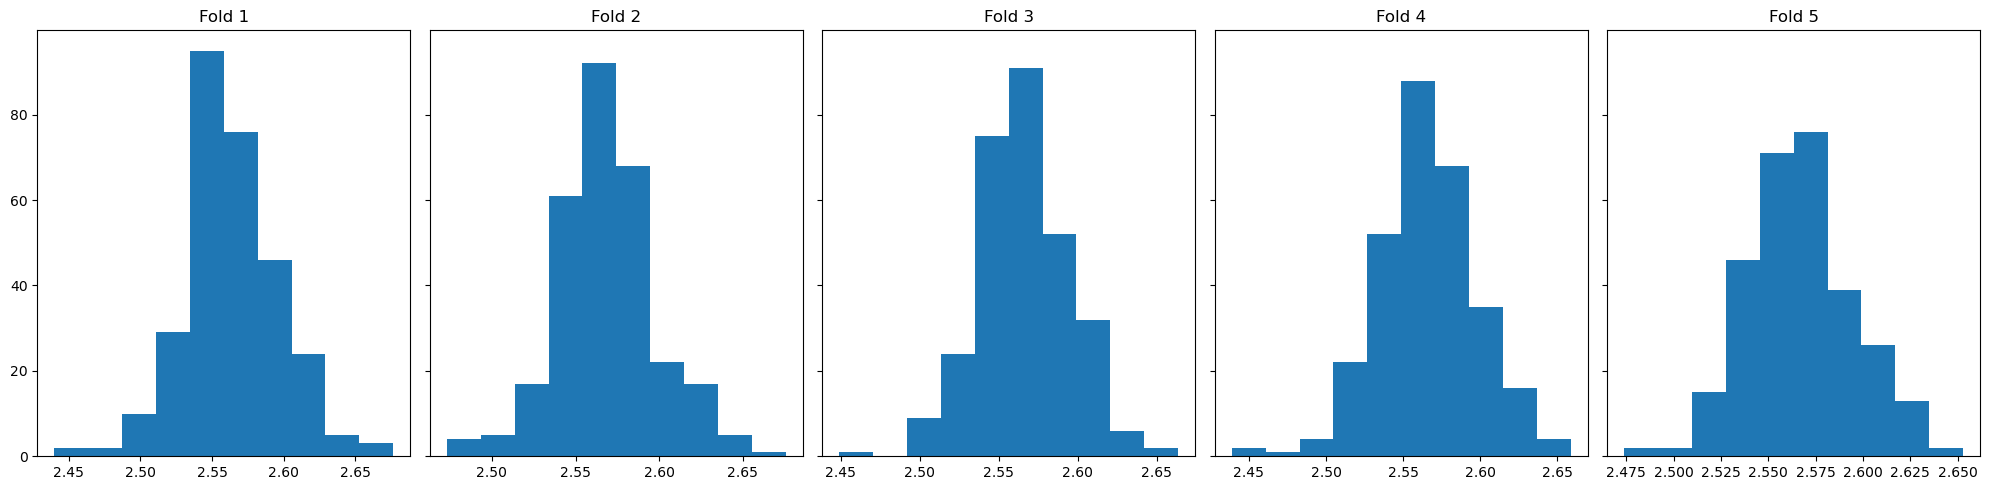

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for i, (train_idx, valid_idx) in enumerate(kf.split(x)):
    x_train = x.iloc[train_idx]
    x_valid = x.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    axes[i].hist(np.log1p(y_valid))
    axes[i].set_title(f"Fold {i+1}")

plt.tight_layout()
plt.savefig(r"C:\Users\81805\python_practice\2026_8_6Y_valid_hist.png", dpi=300, bbox_inches="tight")
plt.show()


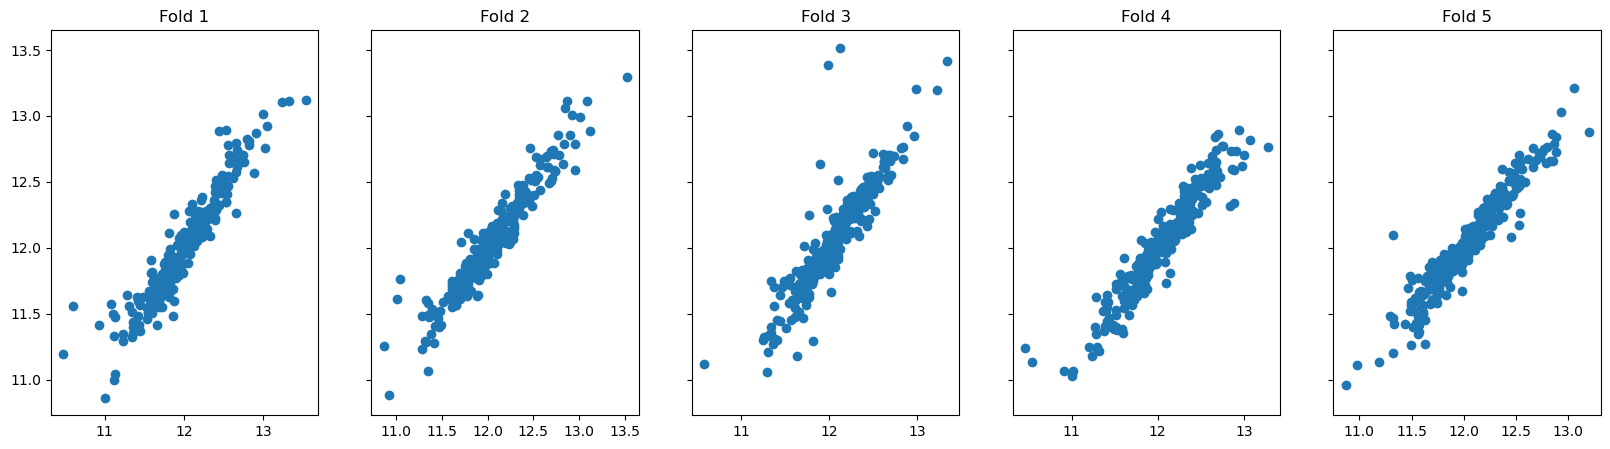

In [25]:
lgb_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", lgb.LGBMRegressor(
        n_estimators=250,
        min_child_samples=5,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ))
])
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for i, (train_idx, valid_idx) in enumerate(kf.split(x)):
    x_train = x.iloc[train_idx]
    x_valid = x.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    # foldごとに未学習のPipelineを複製
    fold_pipeline = clone(lgb_pipeline)
        
    # 前処理もモデルも、X_trainだけでfitされる
    fold_pipeline.fit(x_train, y_train)
    
    pred = fold_pipeline.predict(x_valid)

    axes[i].scatter(y_valid, pred)
    axes[i].set_title(f"Fold {i+1}")
plt.savefig(r"C:\Users\81805\python_practice\2026_8_6tra_pred_scat.png", dpi=300, bbox_inches="tight")
plt.show()    

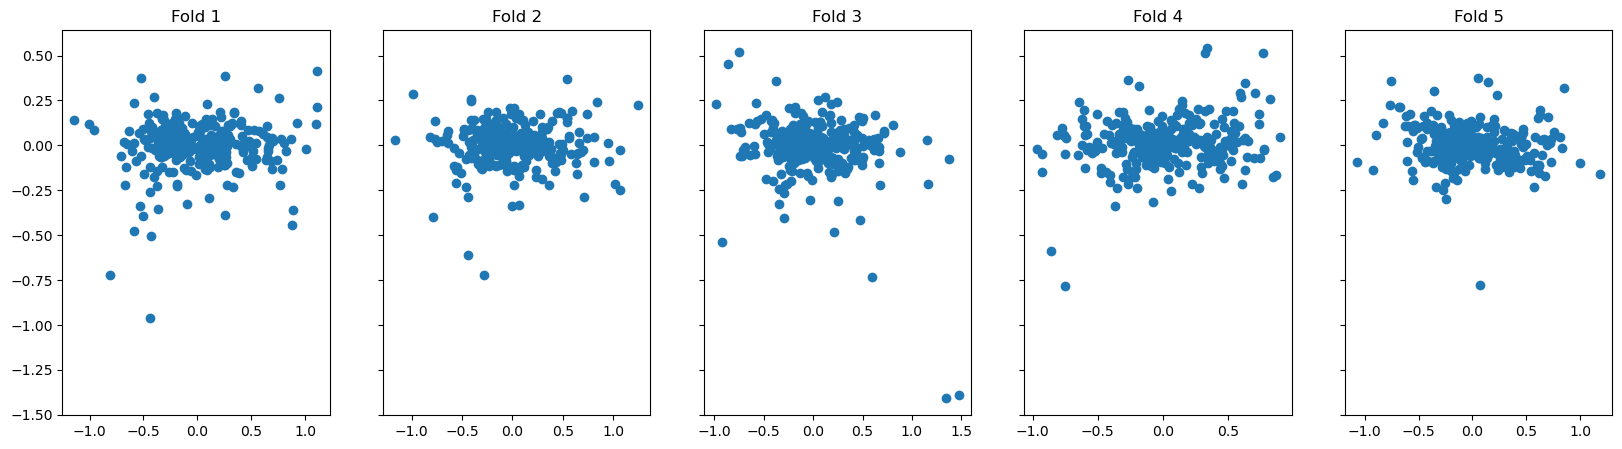

In [27]:
lgb_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", lgb.LGBMRegressor(
        n_estimators=250,
        min_child_samples=5,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ))
])
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for i, (train_idx, valid_idx) in enumerate(kf.split(x)):
    x_train = x.iloc[train_idx]
    x_valid = x.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    # foldごとに未学習のPipelineを複製
    fold_pipeline = clone(lgb_pipeline)
        
    # 前処理もモデルも、X_trainだけでfitされる
    fold_pipeline.fit(x_train, y_train)
    
    pred = fold_pipeline.predict(x_valid)

    axes[i].scatter(pred-pred.mean(), y_valid - pred)
    axes[i].set_title(f"Fold {i+1}")
plt.savefig(r"C:\Users\81805\python_practice\2026_8_6tra_pred-scat.png", dpi=300, bbox_inches="tight")
plt.show()    

In [29]:
for i, (train_idx, valid_idx) in enumerate(kf.split(x)):
    x_train = x.iloc[train_idx]
    x_valid = x.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    fold_pipeline = clone(lgb_pipeline)   # 見たいモデル
    fold_pipeline.fit(x_train, y_train)

    pred = fold_pipeline.predict(x_valid)

    if i == 2:
        error = x_valid.copy()
    
        error["true"] = y_valid
        error["pred"] = pred
        error["abs_error"] = np.abs(y_valid - pred)
    
        display(error.sort_values("abs_error", ascending=False).head(20))
        break

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,TotalSF,HasPool,HasGarage,HasFireplace,HouseAge,RemodAge,TotalBathrooms,true,pred,abs_error
1298,60,RL,63887,Pave,IR3,Bnk,AllPub,Corner,Gtl,Edwards,...,11752,1,1,1,0,0,4.5,11.982935,13.388029,1.405094
523,60,RL,40094,Pave,IR1,Bnk,AllPub,Inside,Gtl,Edwards,...,7814,0,1,1,0,-1,4.5,12.126764,13.516499,1.389735
1324,20,RL,9986,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,...,3590,0,1,1,1,0,2.0,11.898195,12.633225,0.735030
533,20,RL,5000,Pave,Reg,Low,AllPub,Inside,Mod,BrkSide,...,334,0,0,0,61,57,1.0,10.579005,11.117964,0.538959
970,50,RL,10800,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,1912,0,0,0,57,56,1.5,11.813037,11.292335,0.520703
666,60,RL,18450,Pave,IR1,Lvl,AllPub,Inside,Gtl,NAmes,...,3401,0,1,1,42,28,2.5,11.767575,12.251922,0.484347
1212,30,RL,9340,Pave,Reg,Lvl,AllPub,Inside,Gtl,Edwards,...,1344,0,1,0,68,59,2.0,11.635152,11.179711,0.455441
66,20,RL,19900,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,4154,0,1,1,40,21,3.0,12.100718,12.514226,0.413508
1453,20,RL,17217,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,...,2280,0,0,0,0,0,1.0,11.344519,11.748537,0.404019
142,50,RL,8520,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,...,2295,0,1,0,58,58,2.0,12.019749,11.661736,0.358013


In [31]:
import pandas as pd
import numpy as np
import lightgbm as lgb

x = train
y = np.log1p(target)

lgb_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", lgb.LGBMRegressor(
        n_estimators=250,
        min_child_samples=5,
        random_state=42,
        verbose=-1,
        n_jobs=-1,
        importance_type="gain"
    ))
])
# Pipeline全体を学習
lgb_pipeline.fit(x, y)

# 学習済みLightGBMを取り出す
train_model = lgb_pipeline.named_steps["model"]

# 前処理後の特徴量名を取得
feature_names = (
    lgb_pipeline
    .named_steps["transformer"]
    .get_feature_names_out()
)

# importanceをSeries化
importance = pd.Series(
    train_model.feature_importances_,
    index=feature_names
)

importance = importance.sort_values(ascending=False)

print(importance.head(20))

num__OverallQual         518.027155
num__TotalSF             389.415686
cat__CentralAir_N         26.612257
num__TotalBathrooms       24.975640
num__LotArea              19.896821
num__GrLivArea            18.681021
num__OverallCond          17.495060
num__GarageCars           16.542807
num__GarageArea           15.635365
num__BsmtFinSF1           12.242731
num__YearRemodAdd         11.395773
num__RemodAge              9.904439
num__YearBuilt             8.648739
num__HouseAge              8.587490
num__Fireplaces            7.443446
num__BsmtUnfSF             6.861457
num__1stFlrSF              5.722383
cat__MSZoning_C (all)      5.297479
num__2ndFlrSF              4.616659
num__TotalBsmtSF           4.469231
dtype: float64


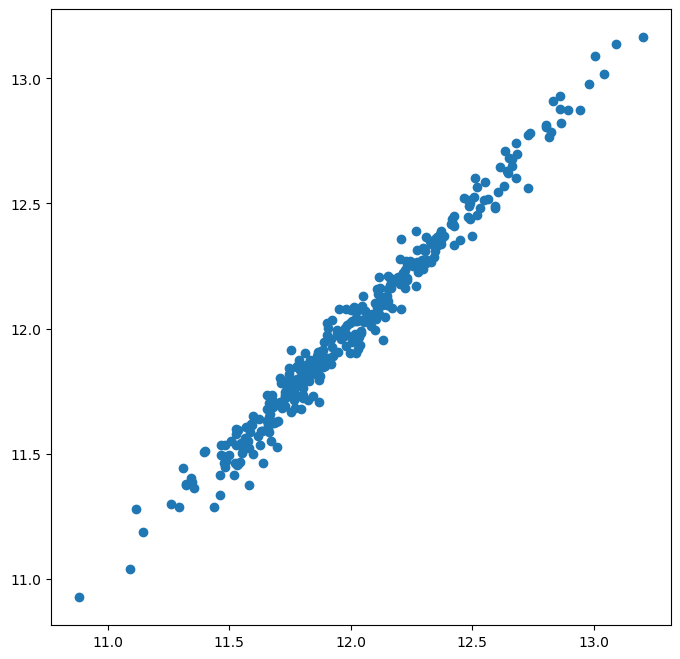

In [33]:
from sklearn.model_selection import train_test_split

x = train
y = np.log1p(target)


x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)

rf_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=250,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", XGBRegressor(
        n_estimators=250,
        min_child_weight=5,
        random_state=42,
        n_jobs=-1
    ))
])
lgb_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", lgb.LGBMRegressor(
        n_estimators=250,
        min_child_samples=5,
        random_state=42,
        verbose=-1,
        n_jobs=-1,
        importance_type="gain"
    ))
])

# Pipeline全体を学習
lgb_pipeline.fit(x_train, y_train)
rf_pipeline.fit(x_train,y_train)
xgb_pipeline.fit(x_train,y_train)

# 学習済みLightGBMを取り出す
train_model1 = lgb_pipeline.named_steps["model"]
train_model2=xgb_pipeline.named_steps["model"]

#予測
pred1 = lgb_pipeline.predict(x_valid)
pred2 = xgb_pipeline.predict(x_valid)

plt.figure(figsize=(8,8))
plt.scatter(pred1,pred2)

plt.show()    

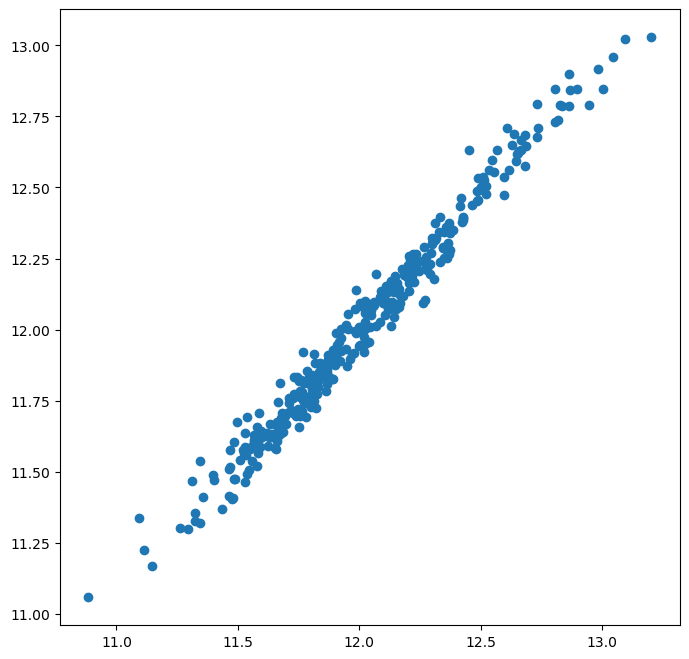

In [35]:
from sklearn.model_selection import train_test_split

x = train
y = np.log1p(target)


x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)

rf_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=250,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", XGBRegressor(
        n_estimators=250,
        min_child_weight=5,
        random_state=42,
        n_jobs=-1
    ))
])
lgb_pipeline = Pipeline([
    ("transformer", preprocessor),
    ("model", lgb.LGBMRegressor(
        n_estimators=250,
        min_child_samples=5,
        random_state=42,
        verbose=-1,
        n_jobs=-1,
        importance_type="gain"
    ))
])

# Pipeline全体を学習
lgb_pipeline.fit(x_train, y_train)
rf_pipeline.fit(x_train,y_train)
xgb_pipeline.fit(x_train,y_train)

# 学習済みLightGBMを取り出す
train_model1 = lgb_pipeline.named_steps["model"]
train_model2=rf_pipeline.named_steps["model"]

#予測
pred1 = lgb_pipeline.predict(x_valid)
pred3 = rf_pipeline.predict(x_valid)

plt.figure(figsize=(8,8))
plt.scatter(pred1,pred3)

plt.show()    

In [37]:
error1 = y_valid - pred1
error2 = y_valid - pred2

print(np.corrcoef(error1, error2)[0, 1])

0.9172735997722514


In [39]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.base import clone


x = train.drop("SalePrice", axis=1)
y = np.log1p(target)

pipelines = {
    "RandomForest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "lightGBM": lgb_pipeline
}

scores = {
    name: np.zeros(5)
    for name in pipelines
}

oof_pred = {
    name: np.zeros(len(x))
    for name in pipelines
}
for i, (train_idx, valid_idx) in enumerate(kf.split(x)):
    x_train = x.iloc[train_idx]
    x_valid = x.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    for name, pipeline in pipelines.items():
        fold_pipeline = clone(pipeline)

        fold_pipeline.fit(x_train, y_train)

        pred = fold_pipeline.predict(x_valid)

        rmse = root_mean_squared_error(y_valid, pred)

        scores[name][i] = rmse
        oof_pred[name][valid_idx] = pred

        print(name)
        print(f"Fold {i}: RMSE = {rmse:.4f}")


RandomForest
Fold 0: RMSE = 0.1513
XGBoost
Fold 0: RMSE = 0.1468
lightGBM
Fold 0: RMSE = 0.1428
RandomForest
Fold 1: RMSE = 0.1262
XGBoost
Fold 1: RMSE = 0.1276
lightGBM
Fold 1: RMSE = 0.1188
RandomForest
Fold 2: RMSE = 0.1715
XGBoost
Fold 2: RMSE = 0.1743
lightGBM
Fold 2: RMSE = 0.1724
RandomForest
Fold 3: RMSE = 0.1470
XGBoost
Fold 3: RMSE = 0.1406
lightGBM
Fold 3: RMSE = 0.1349
RandomForest
Fold 4: RMSE = 0.1235
XGBoost
Fold 4: RMSE = 0.1245
lightGBM
Fold 4: RMSE = 0.1096
